[1] "GSPC"

[1] 0.05174129


,Day_1,Day_2,Day_3,Day_4,Day_5,Day_6,Day_7,Day_8,Day_9,Day_10,⋯,Day_241,Day_242,Day_243,Day_244,Day_245,Day_246,Day_247,Day_248,Day_249,Day_250
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Window_1,NA,-0.0076895319,-0.0054973921,0.0052129486,0.0163591306,-0.0008687668,-0.0031678364,0.0036094239,0.0116870006,0.0142327310,⋯,-0.0052824238,-0.0079974950,-0.0304159821,-0.0072864620,0.0250543939,-0.0043103127,-0.0131317529,-0.0074764855,0.0209598536,0.0218936980
Window_2,-0.0076895319,-0.0054973921,0.0052129486,0.0163591306,-0.0008687668,-0.0031678364,0.0036094239,0.0116870006,0.0142327310,-0.0009744794,⋯,-0.0079974950,-0.0304159821,-0.0072864620,0.0250543939,-0.0043103127,-0.0131317529,-0.0074764855,0.0209598536,0.0218936980,0.0121972087
Window_3,-0.0054973921,0.0052129486,0.0163591306,-0.0008687668,-0.0031678364,0.0036094239,0.0116870006,0.0142327310,-0.0009744794,0.0014730597,⋯,-0.0304159821,-0.0072864620,0.0250543939,-0.0043103127,-0.0131317529,-0.0074764855,0.0209598536,0.0218936980,0.0121972087,0.0115278536
Window_4,0.0052129486,0.0163591306,-0.0008687668,-0.0031678364,0.0036094239,0.0116870006,0.0142327310,-0.0009744794,0.0014730597,0.0042028940,⋯,-0.0072864620,0.0250543939,-0.0043103127,-0.0131317529,-0.0074764855,0.0209598536,0.0218936980,0.0121972087,0.0115278536,-0.0004348494
Window_5,0.0163591306,-0.0008687668,-0.0031678364,0.0036094239,0.0116870006,0.0142327310,-0.0009744794,0.0014730597,0.0042028940,0.0076607935,⋯,0.0250543939,-0.0043103127,-0.0131317529,-0.0074764855,0.0209598536,0.0218936980,0.0121972087,0.0115278536,-0.0004348494,0.0111777589
Window_6,-0.0008687668,-0.0031678364,0.0036094239,0.0116870006,0.0142327310,-0.0009744794,0.0014730597,0.0042028940,0.0076607935,-0.0001961173,⋯,-0.0043103127,-0.0131317529,-0.0074764855,0.0209598536,0.0218936980,0.0121972087,0.0115278536,-0.0004348494,0.0111777589,-0.0124251894
Window_7,-0.0031678364,0.0036094239,0.0116870006,0.0142327310,-0.0009744794,0.0014730597,0.0042028940,0.0076607935,-0.0001961173,0.0032836688,⋯,-0.0131317529,-0.0074764855,0.0209598536,0.0218936980,0.0121972087,0.0115278536,-0.0004348494,0.0111777589,-0.0124251894,0.0141410746
Window_8,0.0036094239,0.0116870006,0.0142327310,-0.0009744794,0.0014730597,0.0042028940,0.0076607935,-0.0001961173,0.0032836688,-0.0041045048,⋯,-0.0074764855,0.0209598536,0.0218936980,0.0121972087,0.0115278536,-0.0004348494,0.0111777589,-0.0124251894,0.0141410746,0.0050406339
Window_9,0.0116870006,0.0142327310,-0.0009744794,0.0014730597,0.0042028940,0.0076607935,-0.0001961173,0.0032836688,-0.0041045048,0.0109724600,⋯,0.0209598536,0.0218936980,0.0121972087,0.0115278536,-0.0004348494,0.0111777589,-0.0124251894,0.0141410746,0.0050406339,0.0070942671


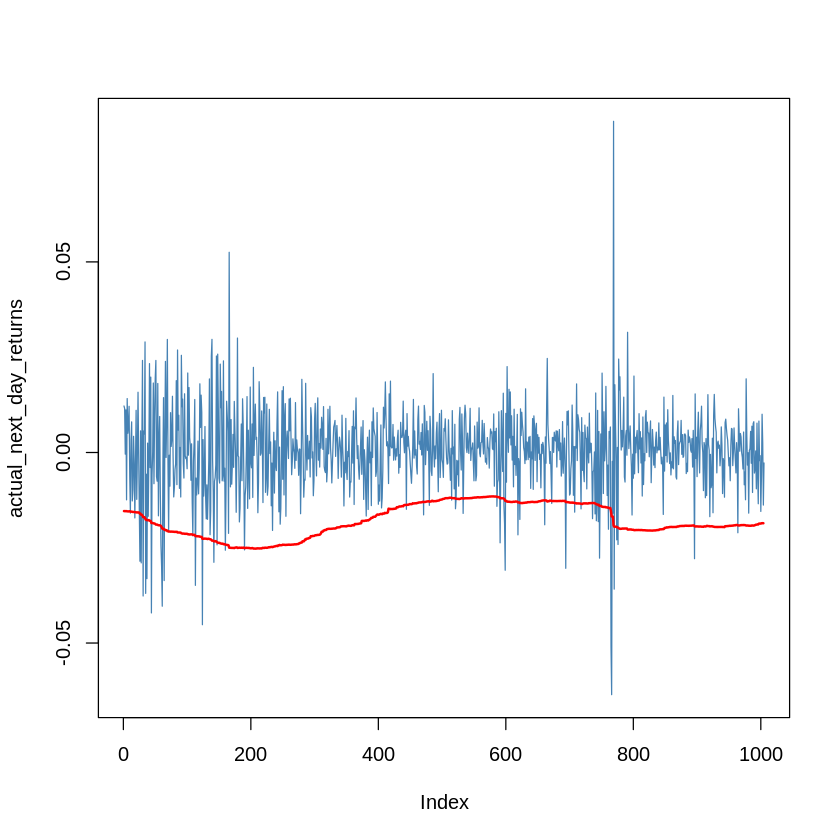

In [5]:
#install.packages("quantmod")
library(quantmod)

## Δεδομένα

getSymbols("^GSPC", src = "yahoo", from = "2021-03-22", to = "2026-03-22")
sp500_prices = Ad(GSPC)


sp500_returns = diff(sp500_prices) / sp500_prices[-length(sp500_prices)]

## Συνάρτηση για κυλιόμενα παράθυρα

create_windows = function(data, K) {

  # data = το εκάστοτε dataset
  # N = το συνολικό μήκος
  N = length(data)

  # Υπολογισμός πόσων παραθύρων χωράνε συνολικά
  # Το τελευταίο παράθυρο ξεκινάει στο N - K + 1
  num_windows = N - K + 1

  # Κενός πίνακας: num_windows γραμμές και K στήλες
  windows_matrix = matrix(NA, nrow = num_windows, ncol = K)

  # Γέμισμα του πίνακα
  for (i in 1:num_windows) {
    # Κάθε γραμμή παίρνει K στοιχεία ξεκινώντας από το i
    windows_matrix[i, ] = data[i:(i + K - 1)]
  }

  return(windows_matrix)
}

# Παράθυρο 250 ημερών (1 χρηματιστηριακό έτος)
K = 250
final_matrix = create_windows(data = sp500_returns, K = K)

#print(final_matrix[, 1:4])
#print(final_matrix[1, 1:10])
## Παράθυρο 1: Ξεκινάει από το 1 και τελειώνει στο 251
## Παράθυρο 2: Ξεκινάει από το 2 και τελειώνει στο 252
## Παράθυρο 3: Ξεκινάει από το 3 και τελειώνει στο 253
## Παράθυρο 4: Ξεκινάει από το 4 και τελειώνει στο 254
#print(final_matrix[, 1:4])
#print(final_matrix[1, 1:10])

## Αρχικοποίση του δυανυσματος αποθήκευσης των εκτιμήσεων VaR
nvar_vector = numeric(nrow(final_matrix))


for (i in 1:nrow(final_matrix)){

  ## Aπομόνωση κάθε παραθύρου ανά γραμμμή

  window_i = final_matrix[i,]

  ## τυπική απόκλιση κάθε παραθύρου

  sigma_i = sd(window_i)

  ## Κρίσιμη τιμη για διαστημα εμπιστοσύνης 95%

  z_score = qnorm(0.05)

  ## Υπολογισμός VaR

  NvaR_95 = sigma_i * z_score

  ## Αποθήκευση σε διάνυσμα
  nvar_vector[i] = NvaR_95
}

## length(nvar_vector) -----> 1256
## length(sp500_returns)----> 1505
## length(K_size)       ----> 250
## 1.505 - 250 + 1 = 1.256

#####################      ΠΑΡΑΒΙΑΣΕΙΣ     #####################

# Αφαιρούμε την τελευταία εκτίμηση VaR επειδή αφορά την επόμενη μέρα
var_forecasts = nvar_vector[1:(length(nvar_vector) - 1)]

## print(length(actual_next_day_returns)
## print(length(var_forecasts)




## καθε VaR παραθύρου συγκρίνετα με την απόδοση της κ+1 μέρες
## VaR_250 ~ r_251 ....
## actual_next_day_returns μέχρι lentgth(..) δίοτι δεν υπάρχει πραγματική απόδοση κ+1
actual_next_day_returns = sp500_returns[(K + 1):length(sp500_returns)]

#print(length(actual_next_day_returns))
#print(length(var_forecasts))
#K = 250

## Αρχικοποίηση του μετρητή παραβιάσεων
counter_violations = 0
n_comparisons = length(var_forecasts)


## Επαναληπτικός βρόγχος  και διανυσματοποίση
for (i in 1:n_comparisons) {

  # i-οστή πραγματική απόδοση
  actual_i = actual_next_day_returns[i]

  # i-οστή εκτίμιση
  var_i = var_forecasts[i]

  # Έλεγχος παραβίασης ------>  "πραγματικόητα σε σύγκριση με εκτίμιση"
  if (!is.na(actual_i) && !is.na(var_i)) { ## Mη κένες λίστες
    if (actual_i < var_i) {
      counter_violations = counter_violations + 1
    }
  }
}

# Υπολογίζουμε το ποσοστό επιτυχίας
percentage = counter_violations / n_comparisons



## Καθαρισμός χρονοσειράς σε απόλυτο νολυμερο
actual_next_day_returns = as.numeric(na.omit(actual_next_day_returns))
var_forecasts = as.numeric(na.omit(var_forecasts))

plot(actual_next_day_returns, type = "l", col = "steelblue" )
lines(var_forecasts, col = "red", lwd = 2)



print(percentage)
df = as.data.frame(final_matrix)
colnames(df) = paste0("Day_", 1:K)
rownames(df) = paste0("Window_", 1:nrow(df))
View(df)

[1] "GSPC"

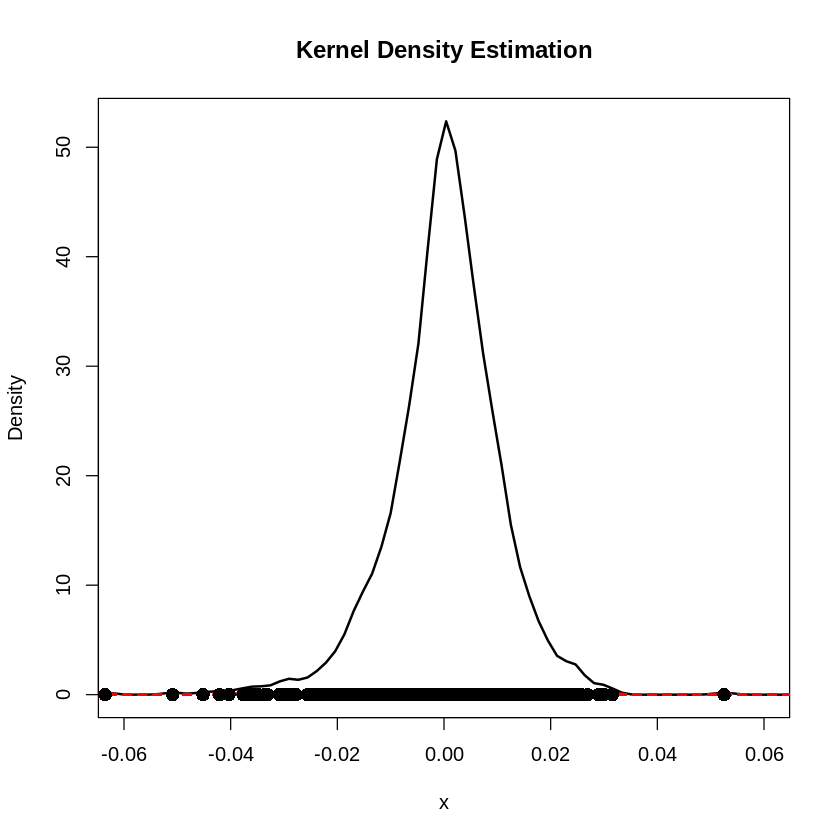

In [15]:
#install.packages("quantmod")
library(quantmod)

## Δεδομένα

getSymbols("^GSPC", src = "yahoo", from = "2021-03-22", to = "2026-03-22")
sp500_prices = Ad(GSPC)


sp500_returns = diff(sp500_prices) / sp500_prices[-length(sp500_prices)]

standard_gaussian_kernel = function(u) {
  (1 / sqrt(2 * pi)) * exp(-0.5 * u^2)
}
bandwidth_silverman = function(data) {
  n = length(data)
  1.06 * sd(data) * (n^(-0.2))
}
bandwidth_robust = function(data) {
  n = length(data)
  0.9 * min(sd(data), IQR(data) / 1.34) * (n^(-0.2))
}
compute_kde = function(data, x_values, kernel_func, h) {
  n = length(data)

  # Υπολογισμός των individual kernels για κάθε σημείο xi του δείγματος
  individual_kernels = sapply(data, function(xi) {
    (1 / (n * h)) * kernel_func((x_values - xi) / h)
  })

  colnames(individual_kernels) = paste0("xi_", data)

  final_kde_estimate = rowSums(individual_kernels)

  return(list(
    kde_total = final_kde_estimate,
    kde_individuals = individual_kernels
  ))
}
## TRAIN DATA
data_sample =  as.numeric((na.omit(sp500_returns)))
## διάστημα για διαγραμμα JB
h_val = bandwidth_robust(data_sample)
min_val = min(data_sample) - sd(data_sample)
max_val = max(data_sample) + sd(data_sample)
x_axis = seq(min_val, max_val, length.out = 100)
#x_axis = seq(0, 10, length.out = 100)
#h_val = 1
results = compute_kde(
  data = data_sample,
  x_values = x_axis,
  kernel_func = standard_gaussian_kernel,
  h = h_val
)
plot(x_axis, results$kde_total, type = "l", ,xlim = c(-0.06, 0.06),ylim = c(0, max(results$kde_total)),
     main = "Kernel Density Estimation",
     xlab = "x", ylab = "Density", lwd = 2)
matlines(x_axis, results$kde_individuals, lty = 2, col = "red", lwd = 1.5)
points(data_sample, rep(0, length(data_sample)), pch = 16, cex = 1.5, col = "black")
final_table = data.frame(
  x_value = x_axis,
  KDE_Total = results$kde_total,
  results$kde_individuals
)